In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv("./data/GSL_daily_climate_data_Jan2017_to_Sep2023.csv")
df.columns

Index(['Unnamed: 0', 'sample_dt', 'mean_air_T(C)', 'avg_wind(m/s)',
       's_pres(kPa)', 'dp_T(C)', 'max_air_T(K)', 'min_air_T(K)', 'evap(m/d)'],
      dtype='object')

In [52]:
df[0+365:30+365]

,Unnamed: 0,sample_dt,mean_air_T(C),avg_wind(m/s),s_pres(kPa),dp_T(C),max_air_T(K),min_air_T(K),evap(m/d),day
365,366,2018-01-02,-2.555556,2.229263,88.187094,-5.806713,273.983333,267.205556,0.000516,1
366,367,2018-01-03,-3.166667,1.339896,87.835342,-6.158565,273.761111,266.205556,0.000443,2
367,368,2018-01-04,-3.000000,1.063057,87.614399,-6.060185,274.372222,265.927778,0.000437,3
368,369,2018-01-05,-2.111111,1.276110,87.654786,-5.723380,275.038889,267.038889,0.000486,4
369,370,2018-01-06,-1.388889,1.683890,87.291205,-3.582176,273.205556,270.316667,0.000459,5
370,371,2018-01-07,-2.861111,1.280397,87.560040,-2.936343,272.538889,268.038889,0.000351,6
371,372,2018-01-08,-1.555556,1.257013,87.068885,-1.306713,272.816667,270.372222,0.000345,7
372,373,2018-01-09,2.000000,2.138929,86.250608,1.723380,278.427778,271.872222,0.000437,8
373,374,2018-01-10,5.138889,3.650894,86.330441,-2.053241,280.427778,276.150000,0.001291,9
374,375,2018-01-11,3.805556,3.178843,87.258404,-3.032407,280.427778,273.483333,0.001113,10


In [49]:
df['day'] = np.mod(df["Unnamed: 0"], 365)
seasonal_df = df[['mean_air_T(C)', 'avg_wind(m/s)', 's_pres(kPa)', 'dp_T(C)', 'max_air_T(K)', 'min_air_T(K)', 'evap(m/d)', 'day']].groupby("day").mean()
seasonal_df

,mean_air_T(C),avg_wind(m/s),s_pres(kPa),dp_T(C),max_air_T(K),min_air_T(K),evap(m/d)
day,,,,,,,
0,-0.145062,3.844086,86.841151,-6.830440,275.310494,270.699383,0.000997
1,-1.509259,3.612777,87.145010,-7.632110,274.239947,269.041534,0.000863
2,-1.604497,2.538614,87.444129,-7.402612,273.864286,269.226720,0.000698
3,-1.416667,2.333891,87.161586,-6.250165,273.903968,269.562698,0.000614
4,-1.238095,2.929427,87.217763,-7.017526,274.554762,269.269048,0.000792
...,...,...,...,...,...,...,...
360,0.044974,4.397078,87.055212,-5.801432,275.660582,270.729365,0.001169
361,-0.107143,4.605147,87.001964,-5.951058,275.340476,270.745238,0.001193
362,-0.482804,3.033693,87.040155,-7.162202,274.933069,270.401323,0.000829


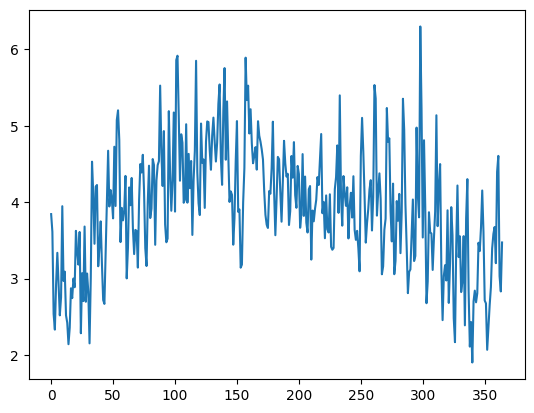

In [5]:
plt.plot(seasonal_df["avg_wind(m/s)"])

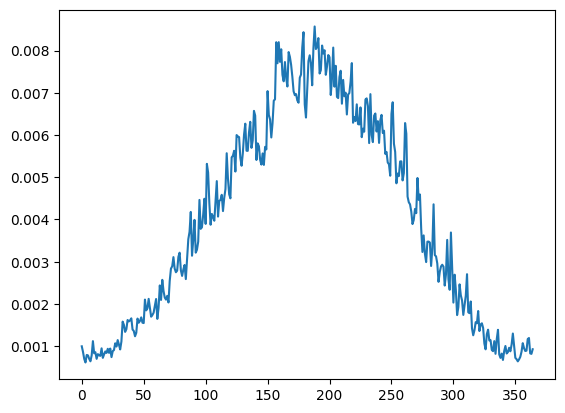

In [6]:
plt.plot(seasonal_df["evap(m/d)"])

In [12]:
def get_vol_to_sa_df(path="./data/elevation-area-volume.csv"):
    df = pd.read_csv(path)
    df["elev"] = df["elev_ft_NAVD88"]
    df = df[["elev", "volume_m3", "area_m2"]]
    return df

def surface_area(volume, df):
    # Note: volume must be in m^3 and surface area will be returned in m^2
    return np.interp(volume, df["volume_m3"], df["area_m2"])

df_sa = get_vol_to_sa_df()

In [ ]:
def get_vp_salinity_df(path="./data/vp-salinity.csv"):
    df = pd.read_csv(path)
    return df

df_es = get_vp_salinity_df()

def vp_reduction(salinity, df):
    return np.interp(salinity, df["salinity"], df["vp_reduction"])

def salinity(volume):
    return 1230618833073.342*(1/volume) + 171886.23798781837*(volume**(-1/3))

def salinity_n(volume):
    return 662924936948.8833*(1/volume) + 462860.60460320744*(volume**(-1/3))

def salinity_s(volume):
    return 1564606058225.5437*(1/volume) + -4334.001932641948*(volume**(-1/3))

# north to south surface area ratio
ratio = 0.615

def vp_reduction_improved(volume, df):
    sal_n = salinity_n(volume)
    sal_s = salinity_s(volume)
    return ratio*np.interp(sal_n, df["salinity"], df["vp_reduction"]) + (1 - ratio)*np.interp(sal_s, df["salinity"], df["vp_reduction"])

In [ ]:
# Weather Functions (Simulating Seasons)
def simulate_temperature(t):
    # Simulates temperature in Celsius over a 365 day year
    # Peaks in summer (around month 7), lowest in winter
    mean_temp = 11.0
    amplitude = 15.0
    # return mean_temp + amplitude * np.sin(2 * np.pi * (t - 110) / 365)
    return 14.41391069*np.sin(2 * np.pi * (t - 110.99496694) / 365) + 13.51914305

def simulate_wind_speed(t):
    # Simulates wind speed in m/s
    mean_wind = 3.0
    amplitude = 1.5
    # return mean_wind + amplitude * np.sin(2 * np.pi * t / 182.5)
    return 1.09434048*np.sin(2 * np.pi * (t - 45.16832821) / 365) + 3.92688972 + 0.57332365*np.sin(2 * np.pi * (t - 199.9250417) / 365)

def calculate_vapor_pressures(T):
    RELATIVE_HUMIDITY = 0.2 # 40% average humidity
    # Magnus-Tetens formula for saturation vapor pressure (kPa)
    es = 0.611 * np.exp((17.27 * T) / (T + 237.3))
    # Actual vapor pressure
    ea = es * RELATIVE_HUMIDITY
    return es, ea

def evap_func(t, V, include_salinity=False, improved=False):
    WIND_COEFF_A = 0.001     # Empirical mass transfer coefficient
    WIND_COEFF_B = 0.0005    # Empirical mass transfer coefficient
    # Get current weather for month t
    T = simulate_temperature(t)
    u = simulate_wind_speed(t)

    # Calculate vapor pressures
    es, ea = calculate_vapor_pressures(T)
    if include_salinity:
        if not improved:
            vp_reduc = vp_reduction(salinity(V), df_es)
        if improved:
            vp_reduc = vp_reduction_improved(V, df_es)
        es = es*(1 - vp_reduc)
    # Calculate Dalton's Evaporation Rate (E)
    # E = f(wind) * (es - ea)
    wind_function = WIND_COEFF_A + WIND_COEFF_B * u
    E = wind_function * (es - ea)

    # Ensure evaporation doesn't go negative
    E = max(E, 0)

    # Calculate Area
    current_area = surface_area(V, df_sa)

    # The Final Differential
    dVdt = -E * current_area
    return dVdt


def calculate_vapor_pressures(T, t):
    # RH = simulate_humidity(t) # 40% average humidity
    RH = 0.2
    # Magnus-Tetens formula for saturation vapor pressure (kPa)
    es = 0.611 * np.exp((17.27 * T) / (T + 237.3))
    # Actual vapor pressure
    ea = es * RH
    return es, ea

def evap_func(t, V, include_salinity=False, improved=False):
    WIND_COEFF_A = 0.0005     # Empirical mass transfer coefficient
    WIND_COEFF_B = 0.00009    # Empirical mass transfer coefficient
    # Get current weather for month t
    T = simulate_temperature(t)
    u = simulate_wind_speed(t)

    # Calculate vapor pressures
    es, ea = calculate_vapor_pressures(T, t)
    if include_salinity:
        if not improved:
            vp_reduc = vp_reduction(salinity(V), df_es)
        if improved:
            vp_reduc = vp_reduction_improved(V, df_es)
        es = es*(1 - vp_reduc)
    # Calculate Dalton's Evaporation Rate (E)
    # E = f(wind) * (es - ea)
    wind_function = WIND_COEFF_A + WIND_COEFF_B * u
    E = wind_function * (es - ea)

    # Ensure evaporation doesn't go negative
    E = max(E, 0)

    # Calculate Area
    current_area = surface_area(V, df_sa)

    # The Final Differential
    dVdt = -E * current_area
    return dVdt

In [84]:
ed_results = []
es_results = []
ea_results = []
for t in range(365):
    dV_dt, E_d, es, ea = evap_func(t, 21963728535, include_salinity=True, improved=True)
    ed_results.append(E_d)
    es_results.append(es)
    ea_results.append(ea)

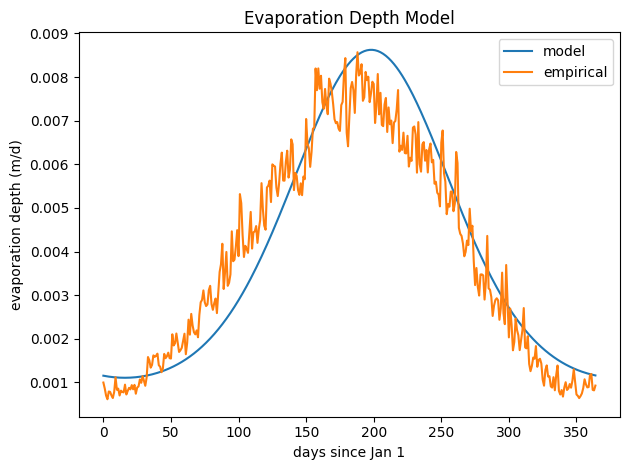

In [91]:
plt.title("Evaporation Depth Model")
plt.plot(np.arange(365), ed_results, label="model")
plt.plot(seasonal_df["evap(m/d)"], label="empirical")
plt.xlabel("days since Jan 1")
plt.ylabel("evaporation depth (m/d)")
plt.legend()
plt.tight_layout()
plt.savefig("./images/evaporation_model.png")

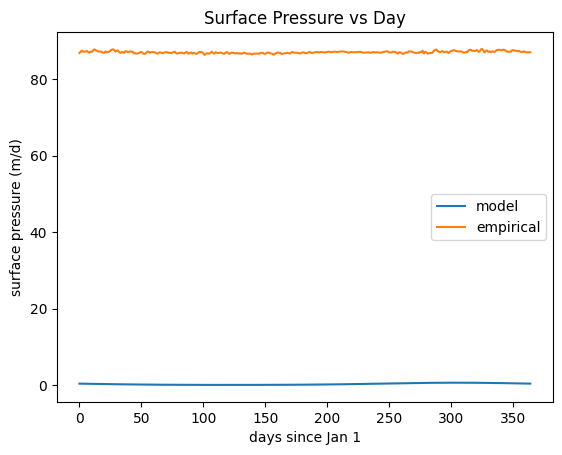

In [39]:
plt.title("Surface Pressure vs Day")
plt.plot(np.arange(365), np.array(ea_results), label="model")
plt.plot(seasonal_df["s_pres(kPa)"], label="empirical")
plt.xlabel("days since Jan 1")
plt.ylabel("surface pressure (m/d)")
plt.legend()

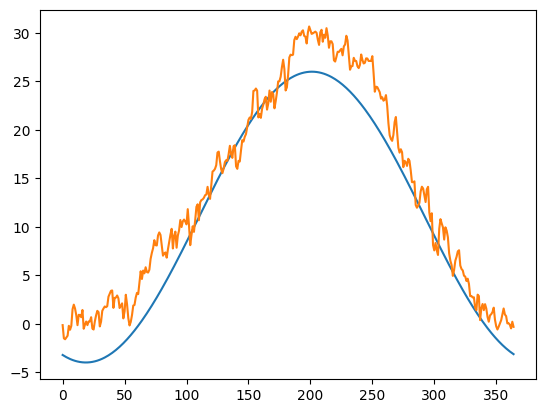

In [62]:
plt.plot(np.arange(365), simulate_temperature(np.arange(365)))
plt.plot(seasonal_df["mean_air_T(C)"])

[ 14.41391069 110.99496694  13.51914305]


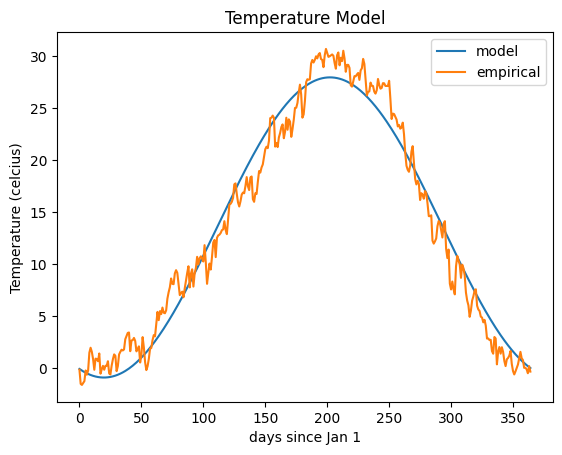

In [92]:
from scipy.optimize import curve_fit

def sin_shifted_scaled(t, scale, t_shift, y_shift):
    return scale*np.sin(2 * np.pi * (t - t_shift) / 365) + y_shift
tdata = np.arange(365)
ydata = seasonal_df["mean_air_T(C)"]
params, cov = curve_fit(sin_shifted_scaled, tdata, ydata, p0=[15, 110, 11.0])
print(params)

def simulate_temperature_fit(t):
    scale, t_shift, y_shift = tuple(params)
    # return sin_shifted_scaled(t, scale, t_shift, y_shift)
    return 14.41391069*np.sin(2 * np.pi * (t - 110.99496694) / 365) + 13.51914305
plt.title("Temperature Model")
plt.xlabel("days since Jan 1")
plt.ylabel("Temperature (celcius)")
plt.plot(np.arange(365), simulate_temperature_fit(np.arange(365)), label="model")
plt.plot(seasonal_df["mean_air_T(C)"], label="empirical")
plt.savefig("./images/temperature_model.png")
plt.legend()

[  1.09434048  45.16832821   3.92688972   0.57332365 199.9250417 ]


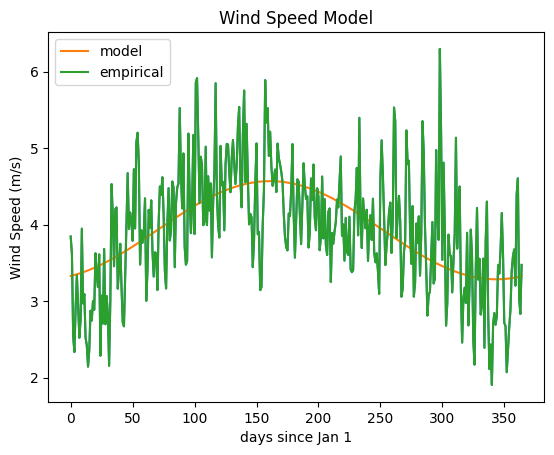

In [93]:
plt.plot(seasonal_df["avg_wind(m/s)"])

def sin_twice_shifted_scaled(t, scale, t_shift, y_shift, scale2, t_shift2):
    return scale*np.sin(2 * np.pi * (t - t_shift) / 365) + y_shift + scale2*np.sin(2 * np.pi * (t - t_shift2) / 365)
tdata = np.arange(365)
ydata = seasonal_df["avg_wind(m/s)"]
params, cov = curve_fit(sin_twice_shifted_scaled, tdata, ydata, p0=[1, 50, 4, 0.5, 150])
print(params)

def simulate_wind_fit(t):
    scale, t_shift, y_shift, scale2, t_shift2 = tuple(params)
    # return sin_twice_shifted_scaled(t, scale, t_shift, y_shift, scale2, t_shift2)
    return 1.09434048*np.sin(2 * np.pi * (t - 45.16832821) / 365) + 3.92688972 + 0.57332365*np.sin(2 * np.pi * (t - 199.9250417) / 365)
    
plt.plot(np.arange(365), simulate_wind_fit(np.arange(365)), label="model")
plt.plot(seasonal_df["avg_wind(m/s)"], label="empirical")
plt.title("Wind Speed Model")
plt.xlabel("days since Jan 1")
plt.ylabel("Wind Speed (m/s)")
plt.savefig("./images/wind_speed_model.png")
plt.legend()

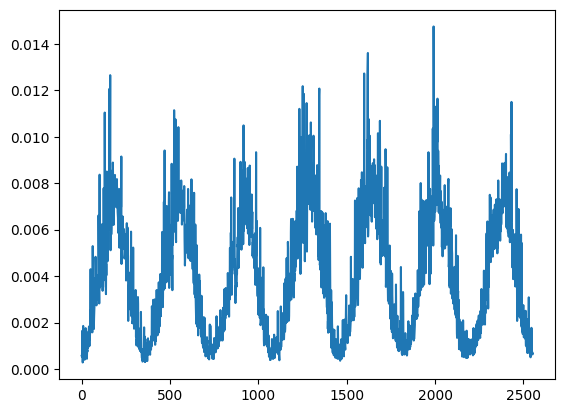

In [ ]:
plt.plot(df["evap(m/d)"])